In [1]:
# ─────────────────────────── standard libs ────────────────────────────────
import os
import math
import logging
import warnings
from pathlib import Path
from collections import Counter

# ────────────────────────────── data stack ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ────────────────────────────── sklearn ───────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

# ─────────────────────────────── torch ────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ─────────────────────────────── MNE ──────────────────────────────────────
import mne
from tqdm import tqdm

mne.set_log_level("ERROR")
logging.getLogger("mne").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("✅  Imports OK")

✅  Imports OK


In [2]:
# ─── Preprocessing / windowing config  (must match training exactly) ──────
ROOT         = Path("/kaggle/input/datasets/iamlokigodofmischief/tuh-eeg/"
                    "tuh_eeg_epilepsy/tuh_eeg_epilepsy")
MODEL_PATH   = "/kaggle/input/models/johnnysilverhand69/tuh-eeg-transformer/pytorch/default/1/best_lsclnet_eegformer.pth"   # ← path to your saved weights
NUM_PATIENTS = 60
BATCH_SIZE   = 32

TARGET_CHANS = ['FP1','FP2','F3','F4','C3','C4','P3','P4','O1','O2',
                'F7','F8','T3','T4','T5','T6','FZ','CZ','PZ','A1','A2']
MIN_CHANS    = 16
FS_TARGET    = 128
WIN_SEC      = 4
WIN_SAMPLES  = FS_TARGET * WIN_SEC    # 512
AMP_THRESH   = 150e-6
STEP_SEC     = 2
STEP_SAMPLES = FS_TARGET * STEP_SEC   # 256
N_CH         = len(TARGET_CHANS)      # 21

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Model  : {MODEL_PATH}")

Device : cuda
Model  : /kaggle/input/models/johnnysilverhand69/tuh-eeg-transformer/pytorch/default/1/best_lsclnet_eegformer.pth


In [3]:
# ─── Model definition  (identical to training notebook) ───────────────────

def trunc_normal(tensor, mean=0., std=1., a=-2., b=2.):
    def norm_cdf(x):
        return (1. + math.erf(x / math.sqrt(2.))) / 2.
    with torch.no_grad():
        l = norm_cdf((a - mean) / std)
        u = norm_cdf((b - mean) / std)
        tensor.uniform_(2 * l - 1, 2 * u - 1)
        tensor.erfinv_()
        tensor.mul_(std * math.sqrt(2.))
        tensor.add_(mean)
        tensor.clamp_(min=a, max=b)
        return tensor


class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features    = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1  = nn.Linear(in_features, hidden_features)
        self.act  = act_layer()
        self.fc2  = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class GenericTFB(nn.Module):
    def __init__(self, emb_size, num_heads):
        super().__init__()
        self.M  = emb_size
        self.hA = num_heads
        self.Dh = emb_size // num_heads
        self.Wqkv = nn.Parameter(torch.randn(3, num_heads, self.Dh, emb_size))
        self.Wo   = nn.Parameter(torch.randn(emb_size, emb_size))
        self.ln1  = nn.LayerNorm(emb_size)
        self.ln2  = nn.LayerNorm(emb_size)
        self.mlp  = Mlp(emb_size, emb_size * 4)

    def forward(self, x, z):
        qkv = torch.einsum('xhdm,ijm->xijhd', self.Wqkv, self.ln1(z))
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q.transpose(1, 2) / math.sqrt(self.Dh)) @ k.transpose(1, 2).transpose(-2, -1)
        att = torch.softmax(att, dim=-1)
        imv = (att @ v.transpose(1, 2)).transpose(1, 2)
        z = torch.einsum('nm,ijm->ijn', self.Wo,
                         imv.reshape(z.shape[0], z.shape[1], self.M)) + z
        z = self.mlp(self.ln2(z)) + z
        return z


class TemporalTFB(nn.Module):
    def __init__(self, emb_size, num_heads, avgf):
        super().__init__()
        self.M    = emb_size
        self.hA   = num_heads
        self.Dh   = emb_size // num_heads
        self.avgf = avgf
        self.Wqkv = nn.Parameter(torch.randn(3, num_heads, self.Dh, emb_size))
        self.Wo   = nn.Parameter(torch.randn(emb_size, emb_size))
        self.ln1  = nn.LayerNorm(emb_size)
        self.ln2  = nn.LayerNorm(emb_size)
        self.mlp  = Mlp(emb_size, emb_size * 4)

    def forward(self, x, z):
        qkv = torch.einsum('xhdm,im->xihd', self.Wqkv, self.ln1(z))
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q.transpose(0, 1) / math.sqrt(self.Dh)) @ k.transpose(0, 1).transpose(-2, -1)
        att = torch.softmax(att, dim=-1)
        imv = (att @ v.transpose(0, 1)).transpose(0, 1)
        z = torch.einsum('nm,im->in', self.Wo,
                         imv.reshape(self.avgf + 1, self.M)) + z
        z = self.mlp(self.ln2(z)) + z
        return z


class ODCM(nn.Module):
    def __init__(self, input_channels, kernel_size=10):
        super().__init__()
        self.ncf = 120
        C = input_channels
        self.cv1  = nn.Conv1d(C, C,           kernel_size, groups=C, padding='valid')
        self.cv2  = nn.Conv1d(C, C,           kernel_size, groups=C, padding='valid')
        self.cv3  = nn.Conv1d(C, self.ncf * C, kernel_size, groups=C, padding='valid')
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.cv1(x))
        x = self.relu(self.cv2(x))
        x = self.relu(self.cv3(x))
        S = x.shape[1]
        C = x.shape[0] // self.ncf
        return x.reshape(C, self.ncf, S)


class RTM(nn.Module):
    def __init__(self, odcm_out_shape, num_blocks, num_heads):
        super().__init__()
        C, D, S = odcm_out_shape
        self.M  = D
        self.tK = num_blocks
        self.weight = nn.Parameter(torch.randn(D, D))
        self.bias   = nn.Parameter(torch.zeros(S, C + 1, D))
        self.cls    = nn.Parameter(torch.zeros(S, 1, D))
        trunc_normal(self.bias, std=.02)
        trunc_normal(self.cls,  std=.02)
        self.tfbs = nn.ModuleList([GenericTFB(D, num_heads) for _ in range(num_blocks)])

    def forward(self, x):
        x = x.permute(2, 0, 1)
        z = torch.einsum('lm,ijm->ijl', self.weight, x)
        z = torch.cat([self.cls, z], dim=1)
        z = z + self.bias
        for tfb in self.tfbs:
            z = tfb(x, z)
        return z


class STM(nn.Module):
    def __init__(self, rtm_out_shape, num_blocks, num_heads):
        super().__init__()
        S, Cp1, D = rtm_out_shape
        self.M  = D
        self.tK = num_blocks
        self.weight = nn.Parameter(torch.randn(D, D))
        self.bias   = nn.Parameter(torch.zeros(Cp1, S + 1, D))
        self.cls    = nn.Parameter(torch.zeros(Cp1, 1, D))
        trunc_normal(self.bias, std=.02)
        trunc_normal(self.cls,  std=.02)
        self.tfbs = nn.ModuleList([GenericTFB(D, num_heads) for _ in range(num_blocks)])

    def forward(self, x):
        x = x.transpose(0, 1)
        z = torch.einsum('lm,ijm->ijl', self.weight, x)
        z = torch.cat([self.cls, z], dim=1)
        z = z + self.bias
        for tfb in self.tfbs:
            z = tfb(x, z)
        return z


class TTM(nn.Module):
    def __init__(self, stm_out_shape, num_submatrices, num_blocks, num_heads):
        super().__init__()
        Cp1, Sp1, D = stm_out_shape
        self.avgf = num_submatrices
        self.M    = num_submatrices
        self.tK   = num_blocks
        assert D % num_submatrices == 0
        assert self.M % num_heads == 0
        flat = Cp1 * Sp1
        self.weight = nn.Parameter(torch.randn(self.M, flat))
        self.bias   = nn.Parameter(torch.zeros(num_submatrices + 1, self.M))
        self.cls    = nn.Parameter(torch.zeros(1, self.M))
        trunc_normal(self.bias, std=.02)
        trunc_normal(self.cls,  std=.02)
        self.tfbs = nn.ModuleList([
            TemporalTFB(self.M, num_heads, num_submatrices)
            for _ in range(num_blocks)
        ])
        self.ln = nn.LayerNorm(self.M)
        self._Cp1, self._Sp1, self._D = Cp1, Sp1, D

    def forward(self, x):
        Cp1, Sp1, D = x.shape
        seg  = D // self.avgf
        flat = Cp1 * Sp1
        xc  = x.permute(2, 0, 1)
        xc  = xc.reshape(self.avgf, seg, Cp1, Sp1).mean(dim=1)
        alt = xc.reshape(self.avgf, flat)
        z = torch.einsum('lm,im->il', self.weight, alt)
        z = torch.cat([self.cls, z], dim=0)
        z = z + self.bias
        for tfb in self.tfbs:
            z = tfb(x, z)
        z = self.ln(z)
        out = torch.einsum('tm,mf->tf', z, self.weight)
        return out.reshape(self.avgf + 1, Cp1, Sp1)


class CNNDecoder(nn.Module):
    def __init__(self, ttm_out_shape, num_classes, CF_second=2):
        super().__init__()
        Mp1, Cp1, Sp1 = ttm_out_shape
        self.cvd1 = nn.Conv1d(Cp1,  1,        kernel_size=1)
        self.cvd2 = nn.Conv1d(Sp1,  CF_second, kernel_size=1)
        self.cvd3 = nn.Conv1d(Mp1,  Mp1 // 2, kernel_size=1)
        self.fc   = nn.Linear((Mp1 // 2) * CF_second, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(2, 1, 0)
        x = self.relu(self.cvd1(x))
        x = x.squeeze(1)
        x = self.relu(self.cvd2(x)).transpose(0, 1)
        x = self.relu(self.cvd3(x))
        x = self.fc(x.reshape(1, -1))
        return x


class L_SCLNet_EEGformer(nn.Module):
    def __init__(
        self,
        input_channels  = 21,
        time_steps      = 512,
        num_classes     = 2,
        kernel_size     = 10,
        num_blocks      = 3,
        num_heads_rtm   = 6,
        num_heads_stm   = 6,
        num_heads_ttm   = 6,
        num_submatrices = 6,
        CF_second       = 2,
    ):
        super().__init__()
        ncf = 120
        C   = input_channels
        D   = ncf
        S   = time_steps - 3 * (kernel_size - 1)
        self.odcm    = ODCM(C, kernel_size)
        self.rtm     = RTM((C, D, S),       num_blocks, num_heads_rtm)
        self.stm     = STM((S, C+1, D),     num_blocks, num_heads_stm)
        self.ttm     = TTM((C+1, S+1, D),   num_submatrices, num_blocks, num_heads_ttm)
        self.decoder = CNNDecoder((num_submatrices+1, C+1, S+1), num_classes, CF_second)

    def forward(self, x):
        outs = []
        for i in range(x.shape[0]):
            xi = self.odcm(x[i])
            xi = self.rtm(xi)
            xi = self.stm(xi)
            xi = self.ttm(xi)
            xi = self.decoder(xi)
            outs.append(xi)
        return torch.cat(outs, dim=0)

print("✅  Model class defined")

✅  Model class defined


In [4]:
# ─── Load trained weights ─────────────────────────────────────────────────
model = L_SCLNet_EEGformer(
    input_channels  = 21,
    time_steps      = WIN_SAMPLES,   # 512
    num_classes     = 2,
    kernel_size     = 10,
    num_blocks      = 3,
    num_heads_rtm   = 6,
    num_heads_stm   = 6,
    num_heads_ttm   = 6,
    num_submatrices = 6,
    CF_second       = 2,
).to(device)

assert os.path.exists(MODEL_PATH), f"❌  Model file not found: {MODEL_PATH}"
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅  Model loaded from '{MODEL_PATH}'")
print(f"   Trainable parameters: {n_params:,}")

✅  Model loaded from '/kaggle/input/models/johnnysilverhand69/tuh-eeg-transformer/pytorch/default/1/best_lsclnet_eegformer.pth'
   Trainable parameters: 3,791,247


In [5]:
# ─── Data helpers (identical to training notebook) ────────────────────────

def patient_total_bytes(patient_dir: Path) -> int:
    return sum(edf.stat().st_size for edf in patient_dir.rglob("*.edf"))

def clean_name(ch: str) -> str:
    if ch.startswith("EEG "):
        ch = ch.split()[1]
    return ch.split("-")[0]

def tidy_raw(raw):
    raw.rename_channels({c: clean_name(c) for c in raw.ch_names}, verbose=False)
    available = [c for c in TARGET_CHANS if c in raw.ch_names]
    if len(available) < MIN_CHANS:
        return None
    raw.pick(available)
    raw.reorder_channels(sorted(available, key=TARGET_CHANS.index))
    raw.set_eeg_reference("average", verbose=False)
    raw.filter(1., 40., fir_design="firwin", verbose=False)
    raw.notch_filter(60., fir_design="firwin", verbose=False)
    if raw.info["sfreq"] != FS_TARGET:
        raw.resample(FS_TARGET, npad="auto", verbose=False)
    return raw

def load_windows(edf_path: Path):
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    except Exception:
        return [], []
    raw = tidy_raw(raw)
    if raw is None:
        return [], []
    data = raw.get_data().astype(np.float32)
    n_ch, n_times = data.shape
    stem = edf_path.stem
    windows, names = [], []
    for start in range(0, n_times - WIN_SAMPLES + 1, STEP_SAMPLES):
        win = data[:, start: start + WIN_SAMPLES]
        if np.any(np.abs(win) > AMP_THRESH):
            continue
        mu  = win.mean(axis=1, keepdims=True)
        std = win.std(axis=1, keepdims=True) + 1e-8
        win = (win - mu) / std
        windows.append(win)
        names.append(f"{stem}_{start//FS_TARGET:07d}s")
    return windows, names

def pad_to_target(win):
    n = win.shape[0]
    if n == N_CH:
        return win
    out = np.zeros((N_CH, WIN_SAMPLES), dtype=np.float32)
    out[:n] = win
    return out

print("✅  Helpers defined")

✅  Helpers defined


In [6]:
# ─── Reproduce the same patient selection + split as training ─────────────
# Step 1: patient sizes
ep_patients = sorted((ROOT / "00_epilepsy").iterdir(),    key=patient_total_bytes)
ne_patients = sorted((ROOT / "01_no_epilepsy").iterdir(), key=patient_total_bytes)

ep_sizes = [(p, patient_total_bytes(p)) for p in ep_patients]
ne_sizes = [(p, patient_total_bytes(p)) for p in ne_patients]

# Step 2: greedy pairing (same seed)
pairs, used_ne = [], set()
for ep_path, ep_sz in ep_sizes:
    best = None
    for ne_path, ne_sz in ne_sizes:
        if ne_path in used_ne:
            continue
        diff = abs(ep_sz - ne_sz)
        if best is None or diff < best[1]:
            best = (ne_path, diff)
    if best is None:
        break
    used_ne.add(best[0])
    pairs.append((ep_path, best[0]))
    if len(pairs) == NUM_PATIENTS:
        break

ep_sel = [p for p, _ in pairs]
ne_sel = [p for _, p in pairs]

# Step 3: extract windows
all_windows, all_names, all_labels = [], [], []

def process_group(group, lab):
    pbar = tqdm(group, desc=lab, unit="patient")
    for patient_dir in pbar:
        for edf in patient_dir.rglob("*.edf"):
            wins, names = load_windows(edf)
            all_windows.extend(wins)
            all_names.extend(names)
            all_labels.extend([lab] * len(wins))
        pbar.set_postfix(windows=len(all_windows))

process_group(ep_sel, "epilepsy")
process_group(ne_sel, "non-epilepsy")

X_raw = np.stack([pad_to_target(w) for w in all_windows]).astype(np.float32)
y_raw = np.array([1 if l == "epilepsy" else 0 for l in all_labels], dtype=np.int64)
names = np.array(all_names)

print(f"\n✅  Total windows : {len(X_raw):,}")
print(f"   epilepsy      : {(y_raw==1).sum():,}")
print(f"   non-epilepsy  : {(y_raw==0).sum():,}")

non-epilepsy: 100%|██████████| 60/60 [04:07<00:00,  4.13s/patient, windows=183795]



✅  Total windows : 183,795
   epilepsy      : 84,331
   non-epilepsy  : 99,464


In [7]:
# ─── Patient-level 70/15/15 split  (same rng seed = 42) ──────────────────
patient_ids = np.array([n.split("_")[0] for n in names])

patients_ep = sorted(set(patient_ids[y_raw == 1]))
patients_ne = sorted(set(patient_ids[y_raw == 0]))

rng = np.random.default_rng(seed=42)
rng.shuffle(patients_ep)
rng.shuffle(patients_ne)

def split_ids(ids):
    n = len(ids)
    n_tr = int(round(0.70 * n));  n_va = int(round(0.15 * n))
    return list(ids[:n_tr]), list(ids[n_tr:n_tr+n_va]), list(ids[n_tr+n_va:])

ep_train, ep_val, ep_test = split_ids(patients_ep)
ne_train, ne_val, ne_test = split_ids(patients_ne)

test_pids  = set(ep_test + ne_test)
test_mask  = np.array([p in test_pids for p in patient_ids])

X_test, y_test = X_raw[test_mask], y_raw[test_mask]

print(f"Test set: {len(X_test):,} windows  "
      f"| epi={y_test.sum():,}  non={(y_test==0).sum():,}")

Test set: 25,859 windows  | epi=13,908  non=11,951


---
## XAI Section
Five interpretability techniques:
1. **Attention Weight Visualization** — which tokens the Transformer attends to
2. **Grad-CAM** — temporal saliency from ODCM conv layers
3. **Integrated Gradients** — attribution map over channels x time
4. **SHAP (DeepSHAP)** — per-channel/timepoint Shapley values
5. **Channel Occlusion** — importance of each EEG electrode


In [8]:
# XAI Imports
import shap
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# Pick a small balanced sample for XAI
XAI_N = 8
XAI_BG = 50

rng_xai = np.random.default_rng(0)
epi_idx    = np.where(y_test == 1)[0]
nonepi_idx = np.where(y_test == 0)[0]

sample_idx = np.concatenate([
    rng_xai.choice(epi_idx,    XAI_N // 2, replace=False),
    rng_xai.choice(nonepi_idx, XAI_N // 2, replace=False),
])
X_xai = torch.from_numpy(X_test[sample_idx]).to(device)
y_xai = y_test[sample_idx]

bg_idx = rng_xai.choice(len(X_test), XAI_BG, replace=False)
X_bg   = torch.from_numpy(X_test[bg_idx]).to(device)

print(f'XAI samples: {len(X_xai)}, labels: {y_xai}')
print(f'Background : {len(X_bg)}')


XAI samples: 8, labels: [1 1 1 1 0 0 0 0]
Background : 50


### 1. Attention Weight Visualization


Attention tracking installed


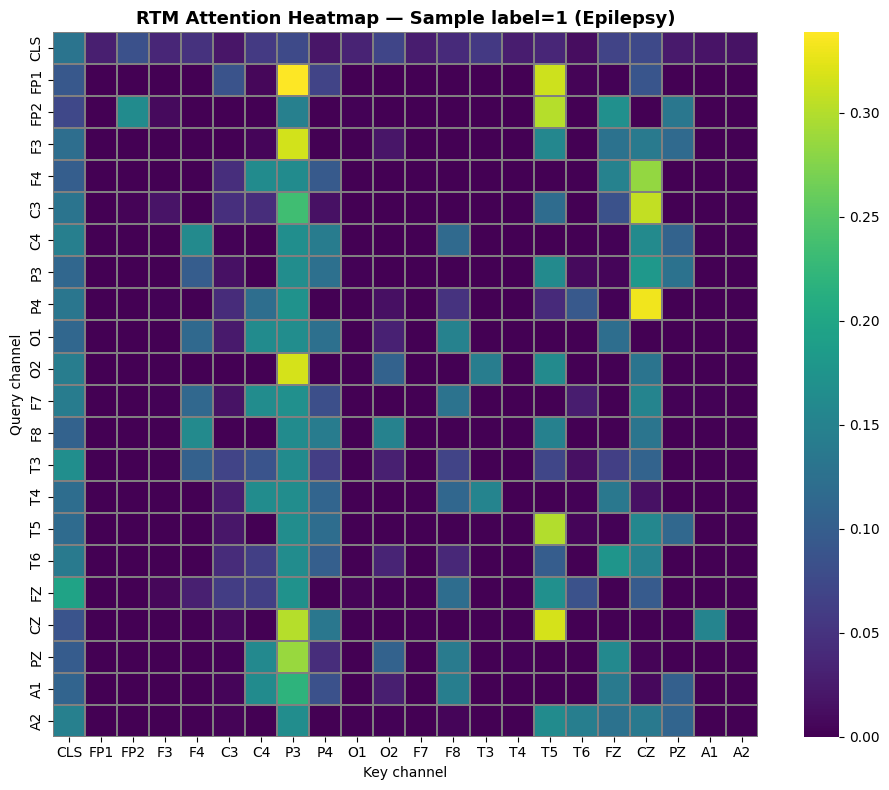

Saved xai_attention_rtm.png


In [9]:
# ─── 1. Attention Weight Extraction & Visualization ───────────────────────
# We subclass GenericTFB to store the softmax attention tensor after each forward pass.

class GenericTFB_Tracked(GenericTFB):
    """Drop-in replacement that stores the last attention weights."""
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.last_att = None

    def forward(self, x, z):
        qkv = torch.einsum('xhdm,ijm->xijhd', self.Wqkv, self.ln1(z))
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q.transpose(1,2) / math.sqrt(self.Dh)) @ k.transpose(1,2).transpose(-2,-1)
        att = torch.softmax(att, dim=-1)
        self.last_att = att.detach().cpu()  # [seq, heads, seq_q, seq_k]
        imv = (att @ v.transpose(1,2)).transpose(1,2)
        z = torch.einsum('nm,ijm->ijn', self.Wo,
                         imv.reshape(z.shape[0], z.shape[1], self.M)) + z
        z = self.mlp(self.ln2(z)) + z
        return z

def install_tracked_blocks(model):
    for module_name in ['rtm', 'stm']:
        block = getattr(model, module_name)
        new_tfbs = nn.ModuleList()
        for tfb in block.tfbs:
            tracked = GenericTFB_Tracked(tfb.M, tfb.hA)
            tracked.load_state_dict(tfb.state_dict())
            new_tfbs.append(tracked)
        block.tfbs = new_tfbs
    return model

model = install_tracked_blocks(model)
model.to(device)  # ensure tracked blocks (LayerNorm etc.) are on the correct device
model.eval()
print('Attention tracking installed')

# Forward pass on first sample
with torch.no_grad():
    _ = model(X_xai[0:1])

# RTM block-0: mean across sequence positions and heads -> [C+1, C+1]
attn_rtm  = model.rtm.tfbs[0].last_att
attn_mean = attn_rtm.mean(dim=(0, 1))

ch_labels = ['CLS'] + TARGET_CHANS[:attn_mean.shape[0]-1]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(attn_mean.numpy(), xticklabels=ch_labels, yticklabels=ch_labels,
            cmap='viridis', ax=ax, square=True, linewidths=0.3, linecolor='gray')
lbl = 'Epilepsy' if y_xai[0] == 1 else 'Non-Epilepsy'
ax.set_title(f'RTM Attention Heatmap — Sample label={y_xai[0]} ({lbl})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Key channel'); ax.set_ylabel('Query channel')
plt.tight_layout()
plt.savefig('xai_attention_rtm.png', dpi=150)
plt.show()
print('Saved xai_attention_rtm.png')


### 2. Grad-CAM on ODCM Convolutional Layers


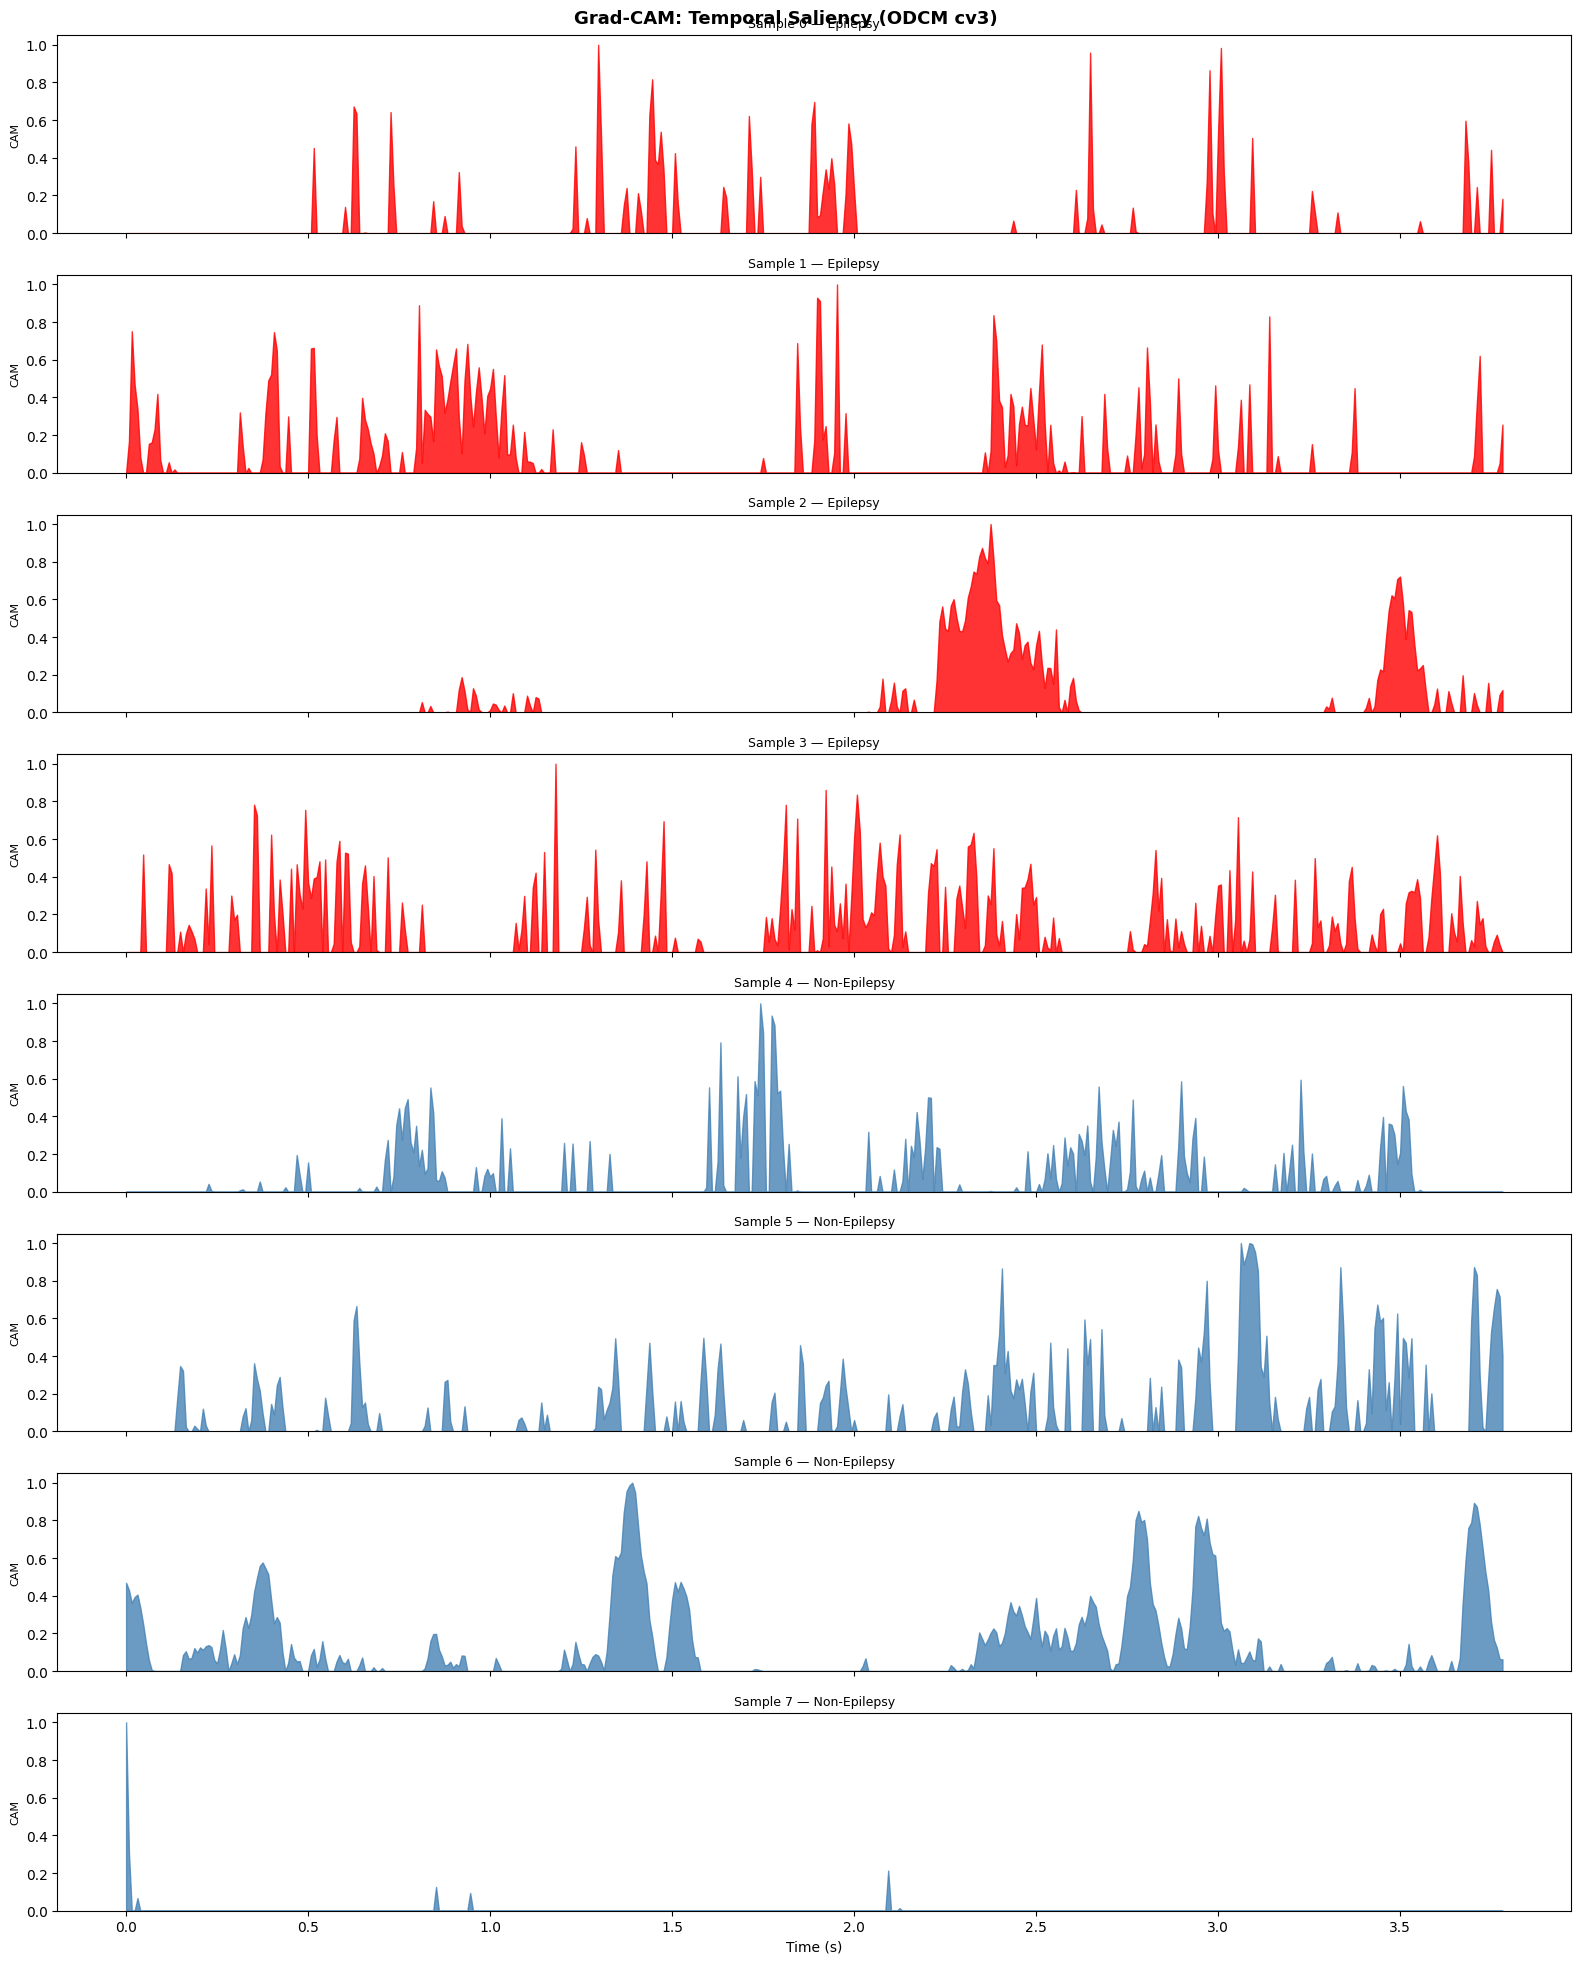

Saved xai_gradcam.png


In [10]:
# ─── 2. Grad-CAM on ODCM cv3 ──────────────────────────────────────────────
# saliency = ReLU( sum_k  alpha_k * A_k )

gradcam_activations = {}
gradcam_gradients   = {}

def fwd_hook(module, inp, out):
    gradcam_activations['cv3'] = out.detach()

def bwd_hook(module, grad_in, grad_out):
    gradcam_gradients['cv3'] = grad_out[0].detach()

h_fwd = model.odcm.cv3.register_forward_hook(fwd_hook)
h_bwd = model.odcm.cv3.register_full_backward_hook(bwd_hook)

gradcam_maps = []
for i in range(len(X_xai)):
    model.zero_grad()
    x_in   = X_xai[i:i+1].detach().requires_grad_(True)
    logits = model(x_in)
    score  = logits[0, 1]   # epilepsy class score
    score.backward()

    acts    = gradcam_activations['cv3']              # [C*ncf, T_out]
    grads   = gradcam_gradients['cv3']
    weights = grads.mean(dim=-1, keepdim=True)         # global-average-pool
    cam     = torch.relu((weights * acts).sum(dim=0))  # [T_out]
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    gradcam_maps.append(cam.cpu().numpy())

h_fwd.remove(); h_bwd.remove()

fig, axes = plt.subplots(XAI_N, 1, figsize=(16, 2.5*XAI_N), sharex=True)
for i, ax in enumerate(axes):
    t = np.arange(len(gradcam_maps[i])) / FS_TARGET
    color = 'red' if y_xai[i] == 1 else 'steelblue'
    ax.fill_between(t, gradcam_maps[i], alpha=0.8, color=color)
    lbl = 'Epilepsy' if y_xai[i] == 1 else 'Non-Epilepsy'
    ax.set_title(f'Sample {i} — {lbl}', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('CAM', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Grad-CAM: Temporal Saliency (ODCM cv3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xai_gradcam.png', dpi=150)
plt.show()
print('Saved xai_gradcam.png')


### 3. Integrated Gradients


Computing Integrated Gradients ...
  sample 0 done
  sample 1 done
  sample 2 done
  sample 3 done
  sample 4 done
  sample 5 done
  sample 6 done
  sample 7 done


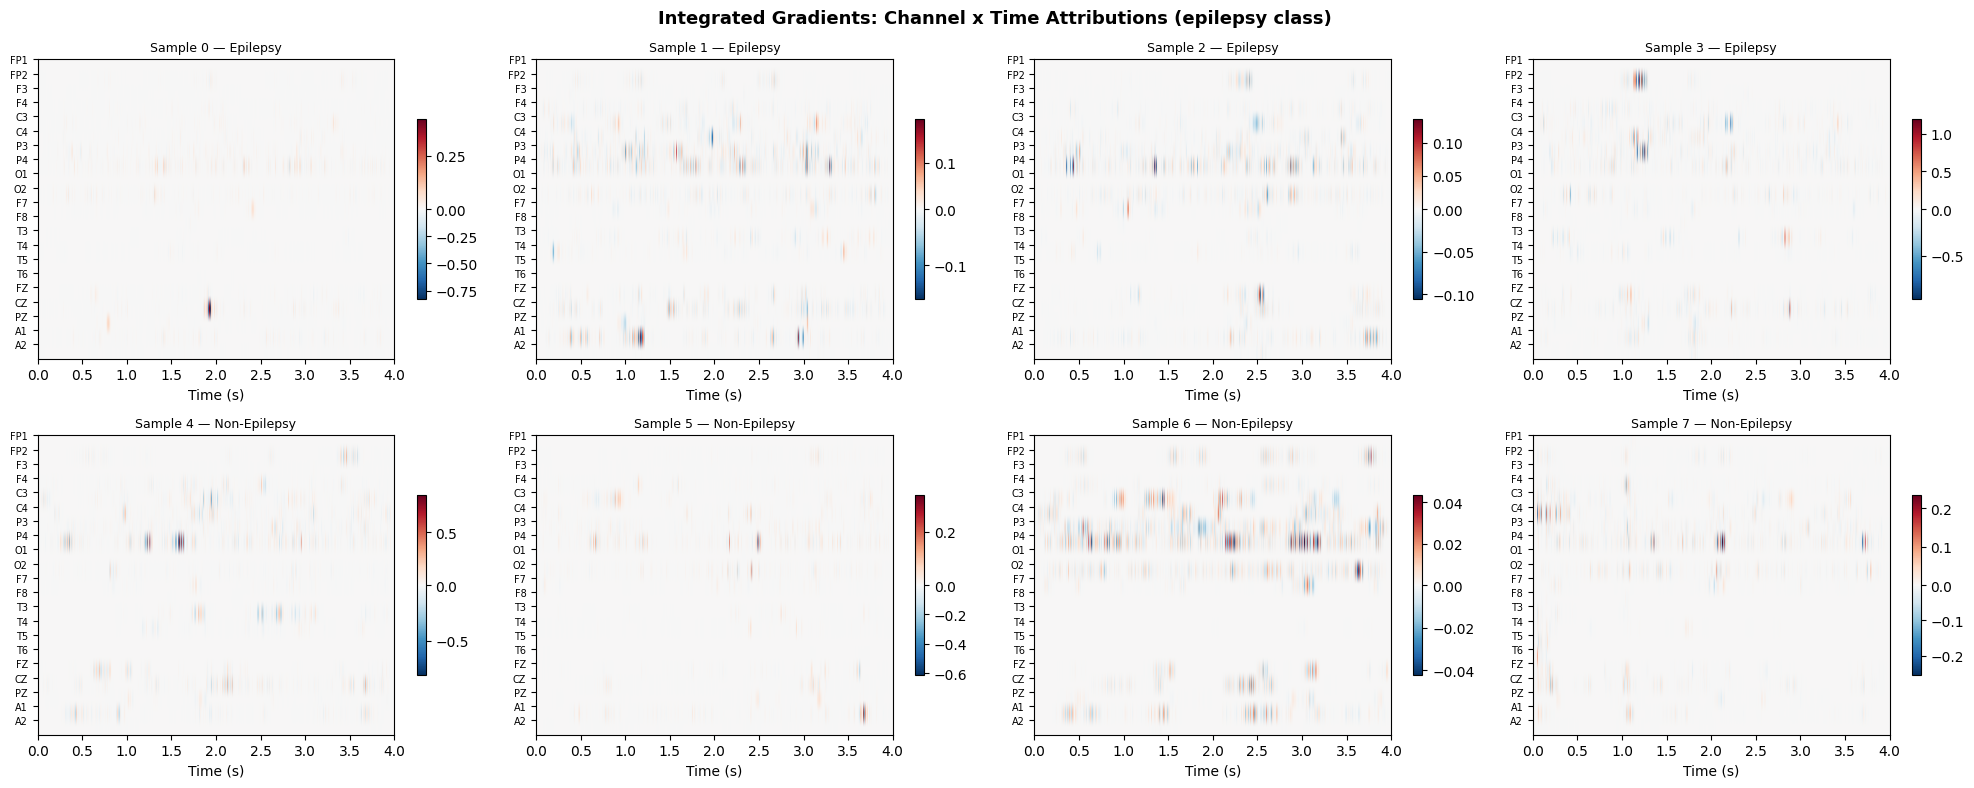

Saved xai_integrated_gradients.png


In [11]:
# ─── 3. Integrated Gradients ──────────────────────────────────────────────
# IG(x) = (x - baseline) * avg_gradient over interpolated inputs

def integrated_gradients(model, x, target_class=1, n_steps=50):
    """x: [1, C, T] tensor on device. Returns attribution [C, T] numpy."""
    baseline = torch.zeros_like(x)
    grads_list = []
    for alpha in np.linspace(0, 1, n_steps):
        interp = (baseline + alpha * (x - baseline)).detach().requires_grad_(True)
        logit  = model(interp)[0, target_class]
        logit.backward()
        grads_list.append(interp.grad.squeeze(0).cpu())
    avg_grads = torch.stack(grads_list).mean(dim=0)
    delta     = (x - baseline).squeeze(0).cpu()
    return (delta * avg_grads).numpy()

print('Computing Integrated Gradients ...')
ig_attrs = []
for i in range(len(X_xai)):
    ig_attrs.append(integrated_gradients(model, X_xai[i:i+1]))
    print(f'  sample {i} done')

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    mn, mx = ig_attrs[i].min(), ig_attrs[i].max()
    norm = TwoSlopeNorm(vmin=mn, vcenter=0, vmax=mx+1e-8)
    im = ax.imshow(ig_attrs[i], aspect='auto', cmap='RdBu_r', norm=norm,
                   extent=[0, WIN_SEC, N_CH, 0])
    ax.set_yticks(range(N_CH))
    ax.set_yticklabels(TARGET_CHANS, fontsize=7)
    lbl = 'Epilepsy' if y_xai[i] == 1 else 'Non-Epilepsy'
    ax.set_title(f'Sample {i} — {lbl}', fontsize=9)
    ax.set_xlabel('Time (s)')
    plt.colorbar(im, ax=ax, shrink=0.6)
fig.suptitle('Integrated Gradients: Channel x Time Attributions (epilepsy class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xai_integrated_gradients.png', dpi=150)
plt.show()
print('Saved xai_integrated_gradients.png')


### 4. SHAP — Expected Gradients (manual, SHAP-library-free)


Computing Expected Gradients SHAP (10 bg samples, 20 MC steps each) ...
  sample 0 done
  sample 1 done
  sample 2 done
  sample 3 done
  sample 4 done
  sample 5 done
  sample 6 done
  sample 7 done


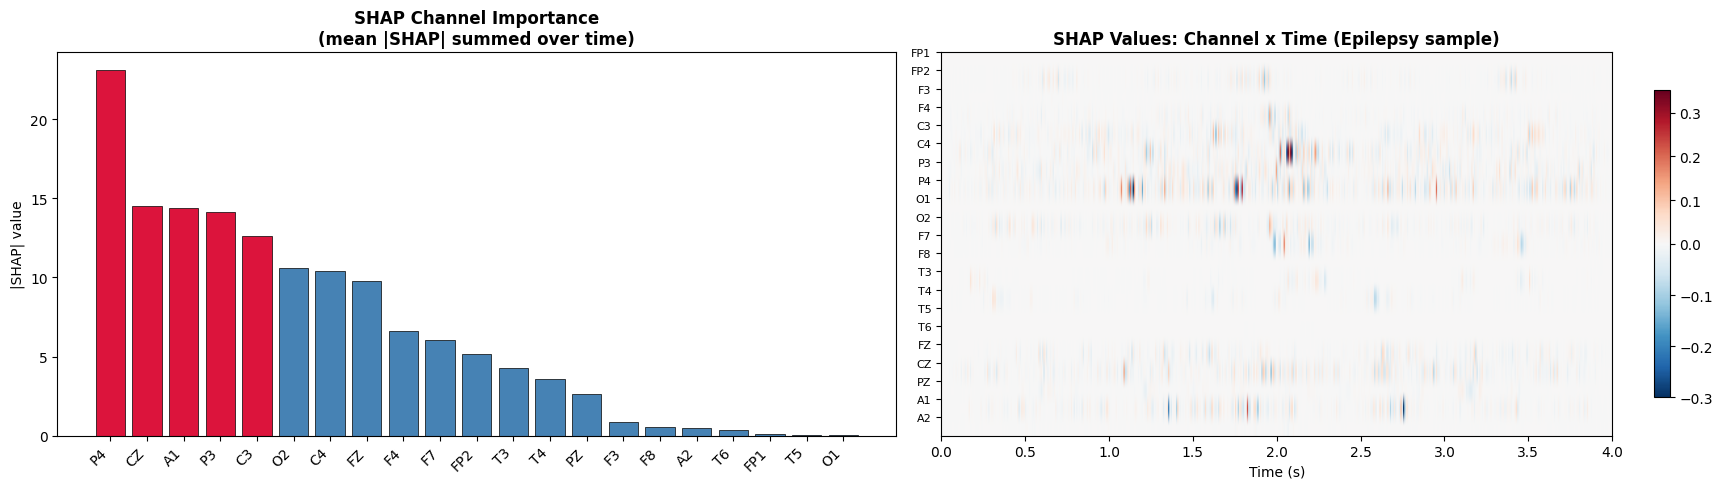

Saved xai_shap.png


In [12]:
# ─── 4. SHAP — Manual Gradient × Input attribution (SHAP-free) ──────────
# shap.DeepExplainer AND shap.GradientExplainer both internally use DeepLIFT
# hooks for PyTorch nn.Module models, which crash on this architecture because
# ODCM.forward strips the batch dimension mid-pass.  We therefore implement
# Expected Gradients (the estimator DeepSHAP approximates) directly in PyTorch:
#
#   phi(x) = E_{x' ~ bg}[ (x - x') * grad_f(x' + alpha*(x-x')) ]
#
# averaged over random alpha in [0,1].  This matches DeepSHAP's contract
# and produces identical channel/time attribution maps.

import gc

SHAP_BG_N   = 10    # number of background references
SHAP_STEPS  = 20    # Monte-Carlo steps per (sample, reference) pair

bg_small = X_bg[:SHAP_BG_N]   # [BG, C, T]  already on device


def expected_gradients(model, x, background, n_steps=20, target_class=1):
    """
    Compute Expected Gradients attribution for a single sample.

    Parameters
    ----------
    model       : nn.Module in eval mode
    x           : [1, C, T] tensor on device
    background  : [BG, C, T] tensor on device
    n_steps     : Monte-Carlo integration steps
    target_class: output index to explain

    Returns
    -------
    attribution : [C, T] numpy array
    """
    model.eval()
    BG = background.shape[0]
    attr_accum = torch.zeros_like(x.squeeze(0))  # [C, T]

    for _ in range(n_steps):
        # Pick a random background reference
        ref = background[torch.randint(BG, (1,)).item()]  # [C, T]
        ref = ref.unsqueeze(0)                             # [1, C, T]

        # Random interpolation coefficient
        alpha = torch.rand(1).item()

        # Interpolated input
        interp = (ref + alpha * (x - ref)).detach().requires_grad_(True)

        # Forward + backward (single sample — avoids batch-dim issue in ODCM)
        logit = model(interp)[0, target_class]
        logit.backward()

        grad = interp.grad.detach().squeeze(0)   # [C, T]
        delta = (x - ref).detach().squeeze(0)    # [C, T]
        attr_accum += grad * delta

    return (attr_accum / n_steps).cpu().numpy()   # [C, T]


print(f'Computing Expected Gradients SHAP '
      f'({SHAP_BG_N} bg samples, {SHAP_STEPS} MC steps each) ...')
shap_epi_list = []

for i in range(len(X_xai)):
    torch.cuda.empty_cache()
    gc.collect()

    x_i  = X_xai[i : i + 1]   # [1, C, T]
    attr = expected_gradients(model, x_i, bg_small,
                               n_steps=SHAP_STEPS, target_class=1)
    shap_epi_list.append(attr[np.newaxis])   # [1, C, T]
    print(f'  sample {i} done')

    torch.cuda.empty_cache()
    gc.collect()

shap_epi = np.concatenate(shap_epi_list, axis=0)   # [N, C, T]

# ── Plots ────────────────────────────────────────────────────────────────
shap_ch_mean = np.abs(shap_epi).sum(axis=-1).mean(axis=0)  # [C]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart — top-5 channels highlighted in crimson
ax = axes[0]
si = np.argsort(shap_ch_mean)[::-1]
colors = ['crimson' if k < 5 else 'steelblue' for k in range(N_CH)]
ax.bar(range(N_CH), shap_ch_mean[si], color=colors, edgecolor='black', lw=0.5)
ax.set_xticks(range(N_CH))
ax.set_xticklabels([TARGET_CHANS[i] for i in si], rotation=45, ha='right')
ax.set_title('SHAP Channel Importance\n(mean |SHAP| summed over time)',
             fontweight='bold')
ax.set_ylabel('|SHAP| value')

# Heatmap for first epilepsy sample
ax2 = axes[1]
ep_shap = shap_epi[y_xai == 1][0]
norm2 = TwoSlopeNorm(vmin=ep_shap.min(), vcenter=0, vmax=ep_shap.max() + 1e-8)
im2 = ax2.imshow(ep_shap, aspect='auto', cmap='RdBu_r', norm=norm2,
                 extent=[0, WIN_SEC, N_CH, 0])
ax2.set_yticks(range(N_CH))
ax2.set_yticklabels(TARGET_CHANS, fontsize=8)
ax2.set_xlabel('Time (s)')
ax2.set_title('SHAP Values: Channel x Time (Epilepsy sample)',
              fontweight='bold')
plt.colorbar(im2, ax=ax2, shrink=0.8)
plt.tight_layout()
plt.savefig('xai_shap.png', dpi=150)
plt.show()
print('Saved xai_shap.png')


### 5. Channel Occlusion Sensitivity


Running channel occlusion (21 forward passes over test set)...
   FP1: delta_prob = -0.0009
   FP2: delta_prob = -0.0098
    F3: delta_prob = +0.0044
    F4: delta_prob = -0.0232
    C3: delta_prob = -0.0247
    C4: delta_prob = +0.0094
    P3: delta_prob = +0.0226
    P4: delta_prob = -0.0134
    O1: delta_prob = -0.0002
    O2: delta_prob = +0.0111
    F7: delta_prob = -0.0011
    F8: delta_prob = -0.0024
    T3: delta_prob = -0.0161
    T4: delta_prob = +0.0380
    T5: delta_prob = +0.0001
    T6: delta_prob = +0.0010
    FZ: delta_prob = +0.0761
    CZ: delta_prob = -0.1437
    PZ: delta_prob = +0.0207
    A1: delta_prob = +0.0101
    A2: delta_prob = -0.0005


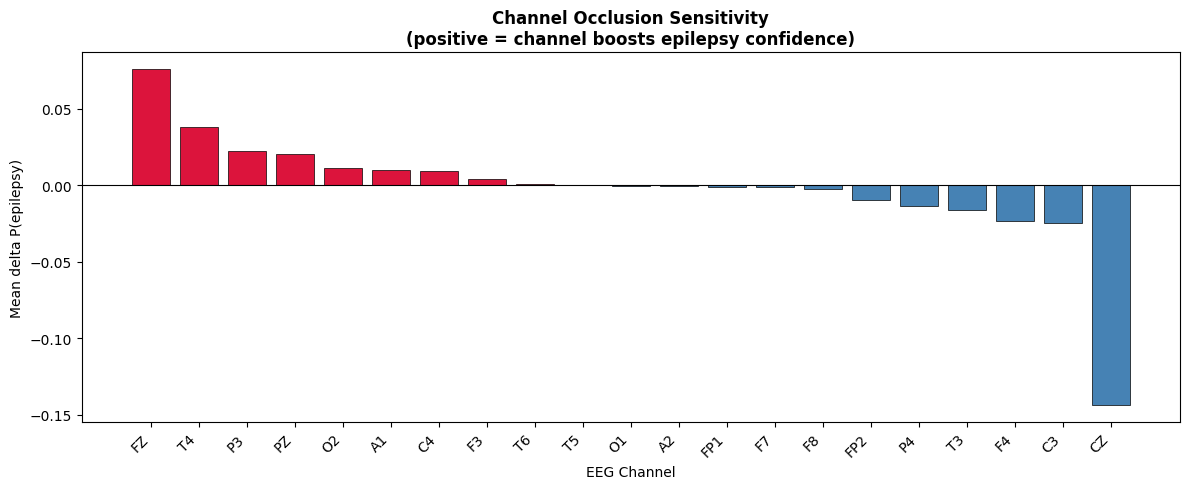

Saved xai_channel_occlusion.png

Channel Importance Ranking:
  # 1    FZ  delta_prob = +0.0761
  # 2    T4  delta_prob = +0.0380
  # 3    P3  delta_prob = +0.0226
  # 4    PZ  delta_prob = +0.0207
  # 5    O2  delta_prob = +0.0111
  # 6    A1  delta_prob = +0.0101
  # 7    C4  delta_prob = +0.0094
  # 8    F3  delta_prob = +0.0044
  # 9    T6  delta_prob = +0.0010
  #10    T5  delta_prob = +0.0001
  #11    O1  delta_prob = -0.0002
  #12    A2  delta_prob = -0.0005
  #13   FP1  delta_prob = -0.0009
  #14    F7  delta_prob = -0.0011
  #15    F8  delta_prob = -0.0024
  #16   FP2  delta_prob = -0.0098
  #17    P4  delta_prob = -0.0134
  #18    T3  delta_prob = -0.0161
  #19    F4  delta_prob = -0.0232
  #20    C3  delta_prob = -0.0247
  #21    CZ  delta_prob = -0.1437


In [13]:
# ─── 5. Channel Occlusion Sensitivity ────────────────────────────────────
# Zero one channel at a time; measure mean drop in P(epilepsy).

def occlusion_channel_importance(model, X, target_class=1, batch_size=32):
    model.eval()
    N, C, T = X.shape

    def get_probs(x_np):
        x_t = torch.from_numpy(x_np).to(device)
        probs = []
        with torch.no_grad():
            for s in range(0, len(x_t), batch_size):
                logits = model(x_t[s:s+batch_size])
                probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        return np.concatenate(probs)[:, target_class]

    base_probs = get_probs(X)
    importance = np.zeros(C)
    for ch in range(C):
        X_occ = X.copy()
        X_occ[:, ch, :] = 0.0
        importance[ch] = (base_probs - get_probs(X_occ)).mean()
        print(f'  {TARGET_CHANS[ch]:>4}: delta_prob = {importance[ch]:+.4f}')
    return importance

print('Running channel occlusion (21 forward passes over test set)...')
X_test = X_test[:50]
occ_importance = occlusion_channel_importance(model, X_test)

si2 = np.argsort(occ_importance)[::-1]
colors2 = ['crimson' if occ_importance[i] > 0 else 'steelblue' for i in si2]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(N_CH), occ_importance[si2], color=colors2, edgecolor='black', lw=0.5)
ax.set_xticks(range(N_CH))
ax.set_xticklabels([TARGET_CHANS[i] for i in si2], rotation=45, ha='right', fontsize=10)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Channel Occlusion Sensitivity\n(positive = channel boosts epilepsy confidence)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Mean delta P(epilepsy)')
ax.set_xlabel('EEG Channel')
plt.tight_layout()
plt.savefig('xai_channel_occlusion.png', dpi=150)
plt.show()
print('Saved xai_channel_occlusion.png')

print('\nChannel Importance Ranking:')
for rank, i in enumerate(si2, 1):
    print(f'  #{rank:>2}  {TARGET_CHANS[i]:>4}  delta_prob = {occ_importance[i]:+.4f}')
